In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/home/vivek/Downloads/zomato_dataset.csv.zip")
print(df)

              Restaurant Name  Dining Rating  Delivery Rating  Dining Votes  \
0                  Doner King            3.9              4.2            39   
1                  Doner King            3.9              4.2            39   
2                  Doner King            3.9              4.2            39   
3                  Doner King            3.9              4.2            39   
4                  Doner King            3.9              4.2            39   
...                       ...            ...              ...           ...   
123652  Ariena Boutique Hotel            3.9              4.2            13   
123653  Ariena Boutique Hotel            3.9              4.2            13   
123654  Ariena Boutique Hotel            3.9              4.2            13   
123655  Ariena Boutique Hotel            3.9              4.2            13   
123656  Ariena Boutique Hotel            3.9              4.2            13   

        Delivery Votes   Cuisine  Place Name       

EDA...

Data Cleaning

In [3]:
df.shape

(123657, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant Name  123657 non-null  str    
 1   Dining Rating    91421 non-null   float64
 2   Delivery Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  str    
 6   Place Name       123657 non-null  str    
 7   City             123657 non-null  str    
 8   Item Name        123657 non-null  str    
 9   Best Seller      27942 non-null   str    
 10  Votes            123657 non-null  int64  
 11  Prices           123657 non-null  float64
dtypes: float64(3), int64(3), str(6)
memory usage: 11.3 MB


In [5]:
df.isnull().sum()

Restaurant Name        0
Dining Rating      32236
Delivery Rating     1280
Dining Votes           0
Delivery Votes         0
Cuisine                0
Place Name             0
City                   0
Item Name              0
Best Seller        95715
Votes                  0
Prices                 0
dtype: int64

In [6]:
df["Dining Rating"]=df["Dining Rating"].fillna(df["Delivery Rating"].mean())
print(df["Dining Rating"])

0         3.9
1         3.9
2         3.9
3         3.9
4         3.9
         ... 
123652    3.9
123653    3.9
123654    3.9
123655    3.9
123656    3.9
Name: Dining Rating, Length: 123657, dtype: float64


In [7]:
df["Delivery Rating"]=df["Delivery Rating"].fillna(df["Delivery Rating"].mean())
print(df["Delivery Rating"])

0         4.2
1         4.2
2         4.2
3         4.2
4         4.2
         ... 
123652    4.2
123653    4.2
123654    4.2
123655    4.2
123656    4.2
Name: Delivery Rating, Length: 123657, dtype: float64


In [8]:
df["Best Seller"]=df["Best Seller"].fillna(df["Best Seller"]).bfill()
print(df["Best Seller"])

0         BESTSELLER
1         BESTSELLER
2         BESTSELLER
3         BESTSELLER
4           MUST TRY
             ...    
123652    BESTSELLER
123653    BESTSELLER
123654    BESTSELLER
123655    BESTSELLER
123656    BESTSELLER
Name: Best Seller, Length: 123657, dtype: str


In [9]:
df.isnull().sum()

Restaurant Name    0
Dining Rating      0
Delivery Rating    0
Dining Votes       0
Delivery Votes     0
Cuisine            0
Place Name         0
City               0
Item Name          0
Best Seller        0
Votes              0
Prices             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(17829)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Votes,Prices
count,105828.000000,105828.000000,105828.00000,105828.000000,105828.000000,105828.000000
mean,3.857519,3.959644,151.70471,116.678847,19.435527,242.321140
std,0.356023,0.245204,230.81093,244.129994,109.509157,196.062694
min,2.500000,2.500000,0.00000,0.000000,0.000000,0.950000
25%,3.700000,3.800000,0.00000,0.000000,0.000000,130.000000
50%,3.963184,4.000000,30.00000,0.000000,0.000000,209.000000
75%,4.000000,4.100000,221.00000,36.000000,11.000000,299.000000
max,4.800000,4.600000,997.00000,983.000000,9750.000000,12024.000000


1. Which Cuisine has the highest number of menu items ? 

In [14]:
df.columns

Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')

In [15]:
cuisine_count = df.groupby("Cuisine ")["Item Name"].count().sort_values(ascending=False).reset_index(name="Count")

print(cuisine_count)

         Cuisine   Count
0       Beverages  34102
1           Pizza  12912
2       Fast Food   9760
3        Desserts   9721
4         Chinese   5297
5         Sichuan   4903
6         Biryani   3587
7           Shake   2892
8    North Indian   2572
9     Street Food   2474
10          Rolls   1623
11   South Indian   1590
12        Seafood   1345
13        Mughlai   1013
14      Ice Cream   1010
15         Bakery    956
16          Momos    884
17            BBQ    739
18          Kebab    714
19       Gujarati    601
20         Burger    598
21         Juices    569
22    Continental    542
23       Sandwich    539
24         Mithai    496
25         Coffee    457
26          Mandi    373
27     Hyderabadi    321
28       American    318
29         Kerala    312
30  Maharashtrian    310
31          Salad    309
32          Pasta    291
33    Kathiyawadi    267
34       Lucknowi    201
35       Shawarma    176
36   Healthy Food    174
37        Mexican    174
38     Rajasthani    172


/tmp/ipykernel_2963/3889537398.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cuisine_count,x="Cuisine ",y="Count",palette="dark")


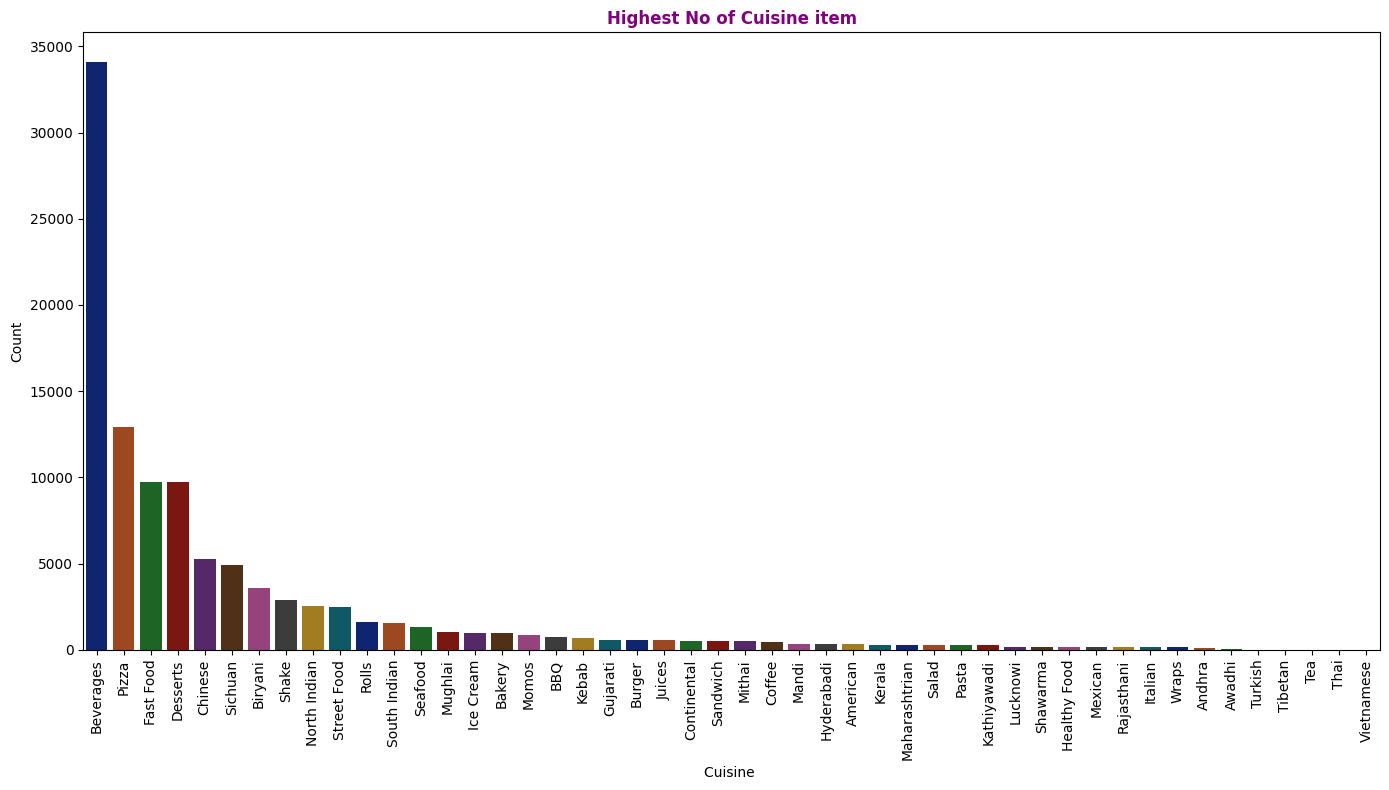

In [16]:
plt.figure(figsize=(14,8))

sns.barplot(data=cuisine_count,x="Cuisine ",y="Count",palette="dark")
plt.title("Highest No of Cuisine item",fontweight="bold",color="Purple")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

2. Which are the top 10 restraunts with the most menu items ? 

In [17]:
top_restraunt=df.groupby('Restaurant Name')["Item Name"].count().sort_values(ascending=False).head(10)
print(top_restraunt)

Restaurant Name
McDonald's           1605
Burger King          1105
FreshMenu            1039
Pizza Hut             974
Domino's Pizza        914
La Pino'z Pizza       749
Subway                683
The Momoz Hub         682
Savoury Sea Shell     577
Kanha                 545
Name: Item Name, dtype: int64


/tmp/ipykernel_2963/531489137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_restraunt,palette="muted")


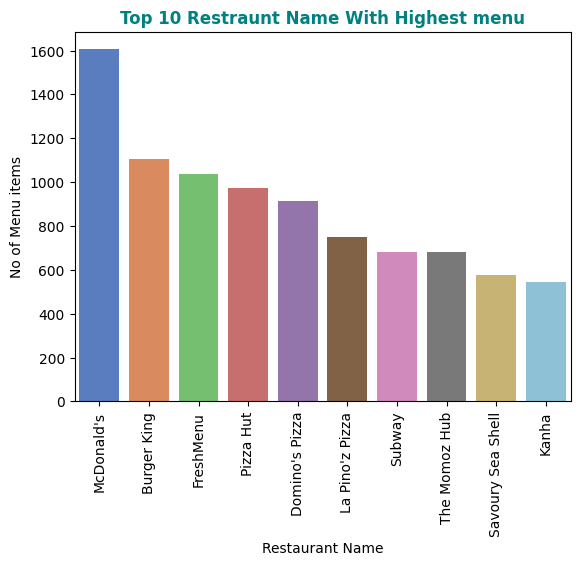

In [47]:
plt.Figure(figsize=(10,5))
sns.barplot(data=top_restraunt,palette="muted")
plt.title("Top 10 Restraunt Name With Highest menu",fontweight="bold",color="Teal")
plt.ylabel("No of Menu items")
plt.xticks(rotation=90)
plt.show()

3. What is the distribution of menu item prices ?

In [19]:
df["Prices"]

0         249.0
1         129.0
2         189.0
3         189.0
4         205.0
          ...  
123631    125.0
123632    125.0
123633    125.0
123634     50.0
123635    195.0
Name: Prices, Length: 105828, dtype: float64

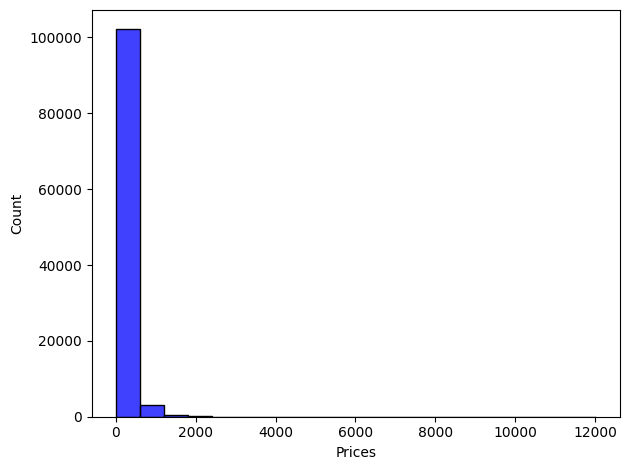

In [20]:

sns.histplot(df["Prices"],color="blue",bins=20)
plt.tight_layout()
plt.show()

4. What are Top 10 menu items with the highest votes?

In [22]:
df[["Item Name","Votes"]]

,Item Name,Votes
0,Platter Kebab Combo,84
1,Chicken Rumali Shawarma,45
2,Chicken Tandoori Salad,39
3,Chicken BBQ Salad,43
4,Special Doner Wrap Combo,31
...,...,...
123631,Fruit Raita,0
123632,Boondi Raita,0
123633,Mint Raita,0
123634,Mint Chutney,0


In [23]:
top_menu=df.groupby("Item Name")["Votes"].count().sort_values(ascending=False).head(10)
print(top_menu)

Item Name
Veg Fried Rice          263
Paneer Butter Masala    238
Jeera Rice              200
Chicken Fried Rice      197
French Fries            175
Egg Fried Rice          167
Butter Naan             161
Chicken Biryani         156
Veg Biryani             149
Dal Fry                 146
Name: Votes, dtype: int64


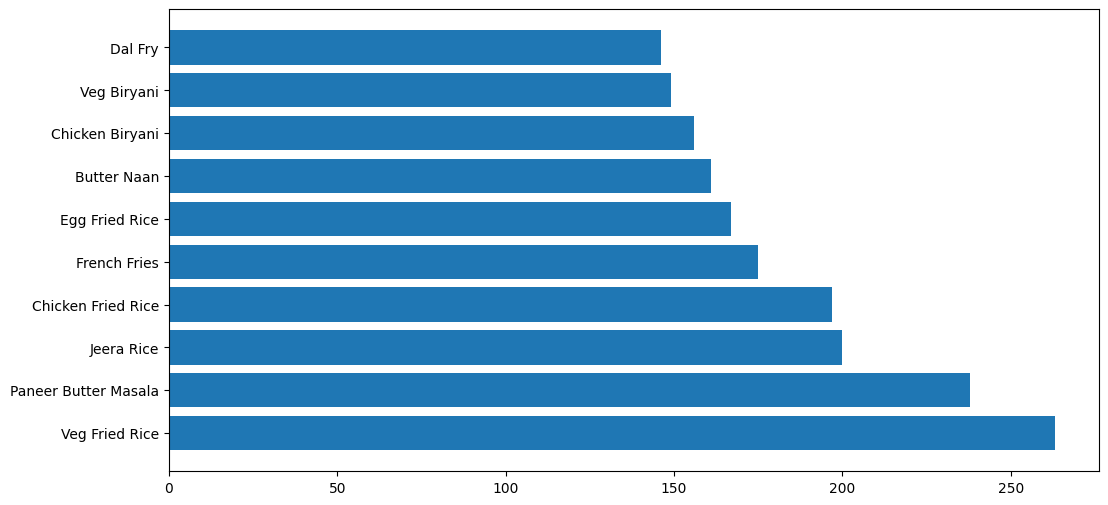

In [46]:
plt.figure(figsize=(12,6))
plt.barh(top_menu.index,top_menu.values,)
plt.show()

5. What percentage of menu items are BESTSELLER, MUST TRY ,CHEF'S SPECIAL ?

In [ ]:
bestseller_count=df["Best Seller"].value_counts(normalize=True) *100 # normalize= number ko fraction mein convert rkan
print(bestseller_count)

Best Seller
BESTSELLER                  70.982160
MUST TRY                     9.947273
CHEF'S SPECIAL               6.144877
Not on Pro                   4.241789
SPICY                        3.953585
Not eligible for coupons     2.763919
NEW                          1.034698
SEASONAL                     0.665230
VEGAN                        0.133235
Eggless available            0.047246
GLUTEN FREE                  0.034017
FODMAP FRIENDLY              0.034017
DAIRY FREE                   0.017954
Name: proportion, dtype: float64


/tmp/ipykernel_2963/3369271848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bestseller_count,palette="deep")


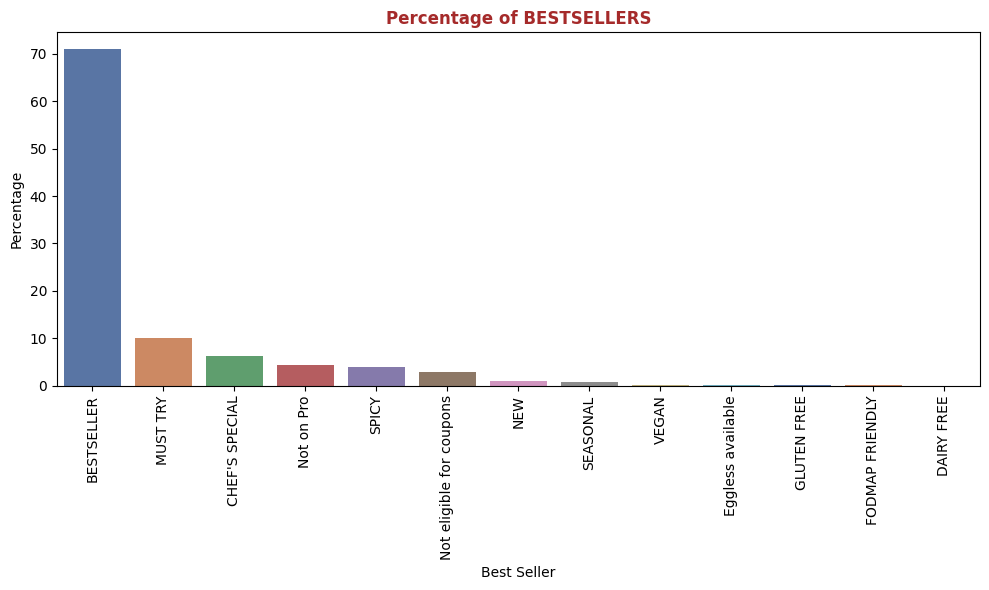

In [115]:
plt.figure(figsize=(10,6))
sns.barplot(data=bestseller_count,palette="deep")
plt.title("Percentage of BESTSELLERS",fontweight="bold",color="Brown")
plt.xticks(rotation=90)
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

In [117]:
bestseller_count=df["Best Seller"].value_counts().sort_values(ascending=False).head(5)
print(bestseller_count)

Best Seller
BESTSELLER        75119
MUST TRY          10527
CHEF'S SPECIAL     6503
Not on Pro         4489
SPICY              4184
Name: count, dtype: int64


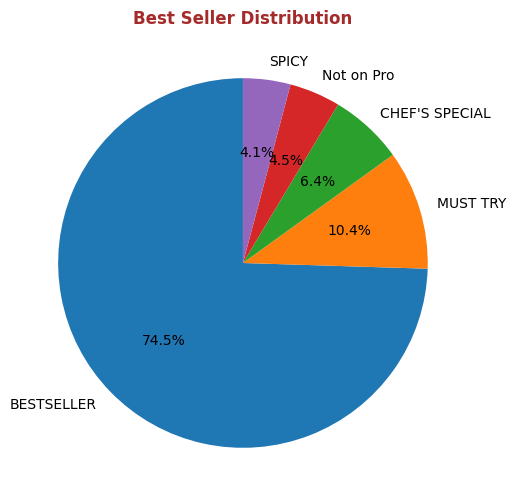

In [121]:
plt.figure(figsize=(6,6))
plt.pie(bestseller_count.values, 
        labels=bestseller_count.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Best Seller Distribution",color="Brown",fontweight="bold")
plt.show()

6. how many restraunt present in each city?

In [26]:
number_restraunt=df.groupby("City")["Restaurant Name"].count()
print(number_restraunt)

City
Ahmedabad        8875
Banaswadi          90
Bangalore        9874
Chennai         11555
Goa              2286
Hyderabad       13585
Jaipur          11576
Kochi            6632
Kolkata          7262
Lucknow          5447
Magrath Road       49
Malleshwaram       32
Mumbai          12005
New Delhi        2987
Pune             6977
Raipur           6536
Ulsoor             60
Name: Restaurant Name, dtype: int64


/tmp/ipykernel_2963/694644875.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=number_restraunt,palette="viridis")


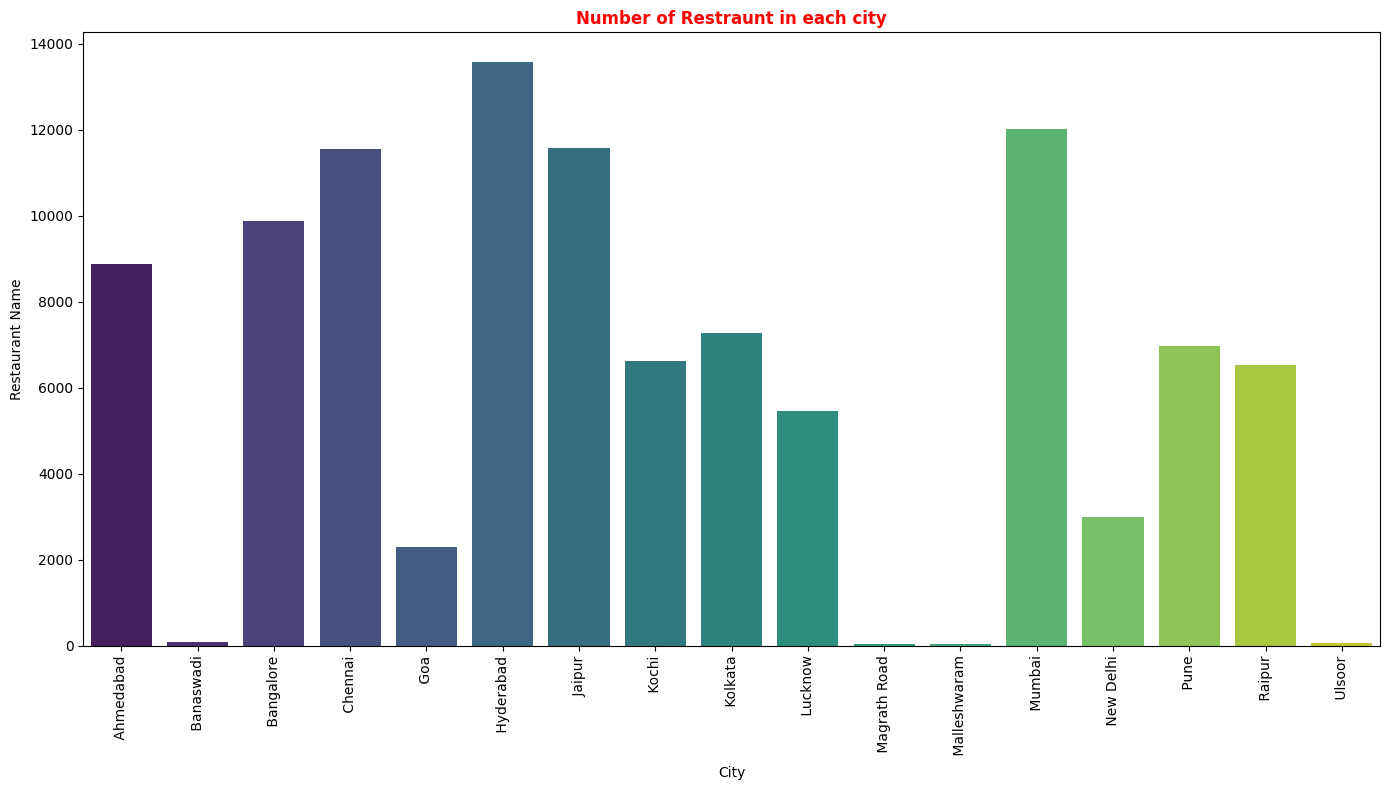

In [27]:
plt.figure(figsize=(14,8))
sns.barplot(data=number_restraunt,palette="viridis")
plt.title("Number of Restraunt in each city",fontweight="bold",color="Red")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

7. What is the average dining rate in each city?

In [28]:
avg_dining=df.groupby("City")["Dining Rating"].mean()
print(avg_dining)

City
Ahmedabad       3.801481
Banaswadi       3.700000
Bangalore       3.785709
Chennai         3.846441
Goa             3.990754
Hyderabad       3.908506
Jaipur          3.818784
Kochi           3.858177
Kolkata         3.855261
Lucknow         3.899103
Magrath Road    3.500000
Malleshwaram    4.000000
Mumbai          3.896761
New Delhi       3.972735
Pune            3.788234
Raipur          3.897301
Ulsoor          3.963184
Name: Dining Rating, dtype: float64


/tmp/ipykernel_2963/157882719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_dining,palette="flare")


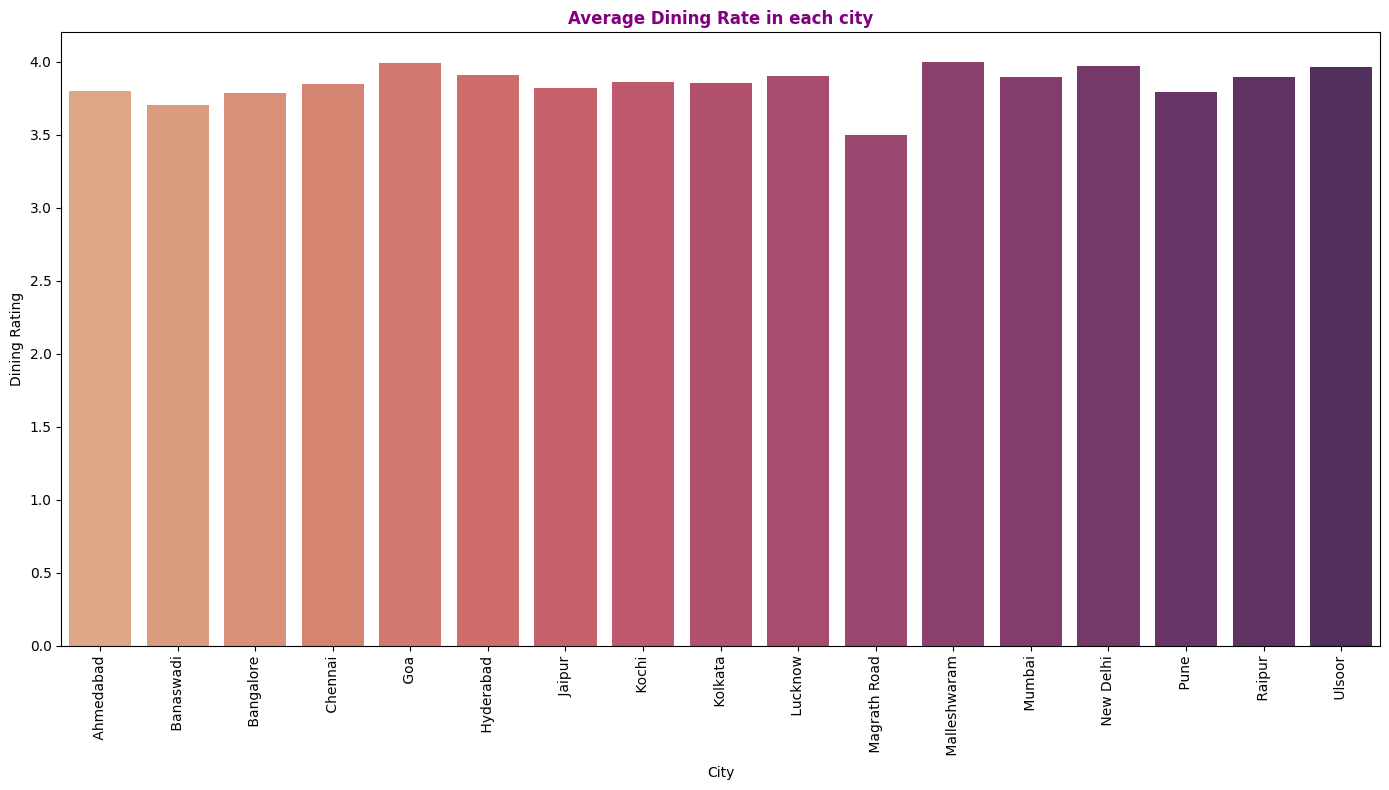

In [49]:
plt.figure(figsize=(14,8))
sns.barplot(data=avg_dining,palette="flare")
plt.title("Average Dining Rate in each city",fontweight="bold",color="purple")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

8. How many item are available in each cuisine?

In [30]:
number_cuisine=df.groupby("Cuisine ")["Item Name"].count().reset_index(name="no of item")
print(number_cuisine)

         Cuisine   no of item
0        American         318
1          Andhra         112
2          Awadhi          50
3             BBQ         739
4          Bakery         956
5       Beverages       34102
6         Biryani        3587
7          Burger         598
8         Chinese        5297
9          Coffee         457
10    Continental         542
11       Desserts        9721
12      Fast Food        9760
13       Gujarati         601
14   Healthy Food         174
15     Hyderabadi         321
16      Ice Cream        1010
17        Italian         168
18         Juices         569
19    Kathiyawadi         267
20          Kebab         714
21         Kerala         312
22       Lucknowi         201
23  Maharashtrian         310
24          Mandi         373
25        Mexican         174
26         Mithai         496
27          Momos         884
28        Mughlai        1013
29   North Indian        2572
30          Pasta         291
31          Pizza       12912
32     Raj

/tmp/ipykernel_2963/3129562881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cuisine ",y="no of item",data=number_cuisine, palette="dark")


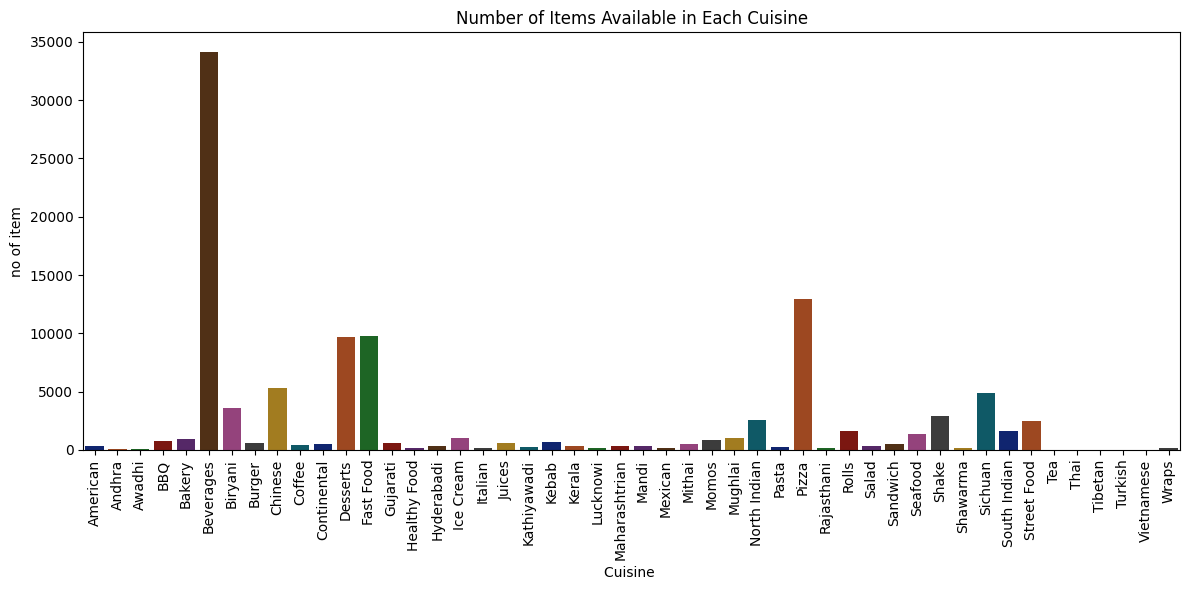

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(x="Cuisine ",y="no of item",data=number_cuisine, palette="dark")
plt.title("Number of Items Available in Each Cuisine")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

9. Is there relationship between menu item price and votes?

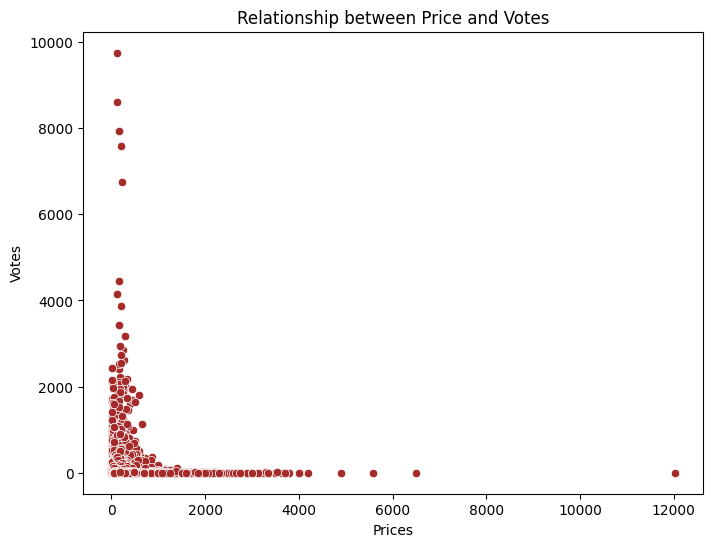

In [61]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Prices",
    y="Votes",
    color="brown"
)

plt.title("Relationship between Price and Votes")
plt.show()

10. what is distribution of dining rating?

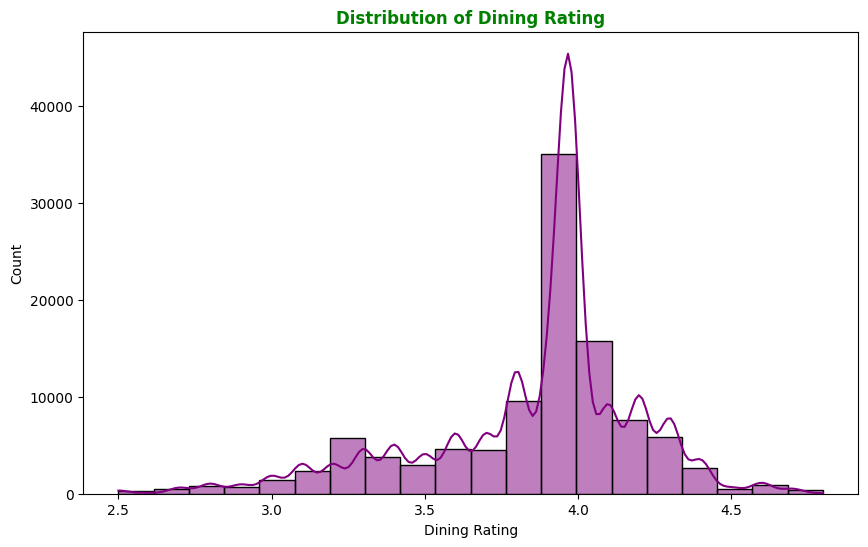

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["Dining Rating"], bins=20, kde=True, color="purple")

plt.title("Distribution of Dining Rating", fontweight="bold", color="green")
plt.xlabel("Dining Rating")
plt.show()

In [126]:
df.columns

Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')